# Quick Start

This notebook shows the minimal workflow: fit Poincaré Maps embeddings on a graph and visualize the result in the Poincaré disk.

In [1]:
# Uncomment to install hypeGRL:
# !pip install git+https://github.com/cicadaUY/hypeGRL

import networkx as nx
import matplotlib
from hypegrl.embedders.poincare_maps import PoincareMapsEmbedder
from hypegrl.visualization.disk import plot_poincare_graph

## Load a graph

We use the Zachary karate club graph as a running example.

In [2]:
G = nx.karate_club_graph()
print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')

Nodes: 34, Edges: 78


## Fit embeddings

In [3]:
embedder = PoincareMapsEmbedder(
    d=2,
    gamma=1.0,
    n_steps=500,
    lr_X=1e-2,
    log_every=50,
    random_state=0,
)
embedder.fit(G)
X = embedder.embeddings()
print(f'Embeddings shape: {X.shape}')

Step    0 | Loss: 12.781372
Step   50 | Loss: 11.329185
Step  100 | Loss: 9.154881
Step  150 | Loss: 6.271541
Step  200 | Loss: 4.599245


Step  250 | Loss: 4.290112
Step  300 | Loss: 4.165060
Step  350 | Loss: 4.103177
Step  400 | Loss: 4.034155
Step  450 | Loss: 4.011997


Step  499 | Loss: 4.005501
Embeddings shape: (34, 2)


## Visualise in the Poincaré disk

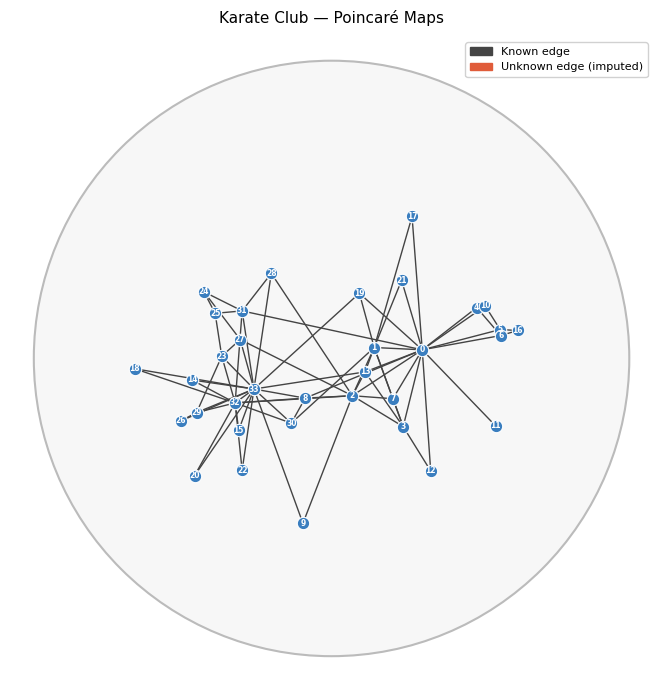

In [4]:
fig = plot_poincare_graph(
    G, X,
    title='Karate Club — Poincaré Maps',
)

## Loss curve

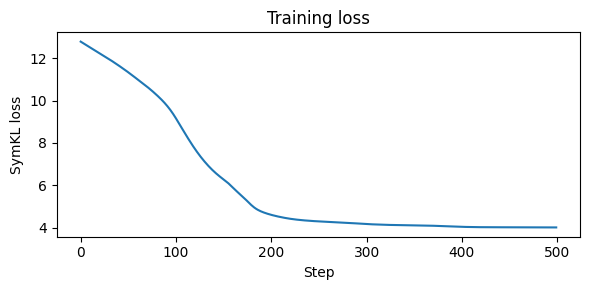

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(embedder.loss_history)
plt.xlabel('Step'); plt.ylabel('SymKL loss')
plt.title('Training loss'); plt.tight_layout()
plt.show()